# Projeto Integrador

## Imports e Análises Iniciais

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql import SparkSession
from pyspark.sql.functions import col
from pyspark.ml.feature import VectorAssembler, StandardScaler, PCA
from pyspark.sql.types import StructType, StructField, StringType, DoubleType, IntegerType, BooleanType
from pyspark.sql import functions as F

from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator

In [3]:
df = pd.read_csv("dados/dataset.csv")
print(df.head())

   Unnamed: 0                track_id                 artists  \
0           0  5SuOikwiRyPMVoIQDJUgSV             Gen Hoshino   
1           1  4qPNDBW1i3p13qLCt0Ki3A            Ben Woodward   
2           2  1iJBSr7s7jYXzM8EGcbK5b  Ingrid Michaelson;ZAYN   
3           3  6lfxq3CG4xtTiEg7opyCyx            Kina Grannis   
4           4  5vjLSffimiIP26QG5WcN2K        Chord Overstreet   

                                          album_name  \
0                                             Comedy   
1                                   Ghost (Acoustic)   
2                                     To Begin Again   
3  Crazy Rich Asians (Original Motion Picture Sou...   
4                                            Hold On   

                   track_name  popularity  duration_ms  explicit  \
0                      Comedy          73       230666     False   
1            Ghost - Acoustic          55       149610     False   
2              To Begin Again          57       210826     False   


In [3]:
df.columns

Index(['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name',
       'popularity', 'duration_ms', 'explicit', 'danceability', 'energy',
       'key', 'loudness', 'mode', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature',
       'track_genre'],
      dtype='object')

In [4]:
df.dtypes

,0
Unnamed: 0,int64
track_id,object
artists,object
album_name,object
track_name,object
popularity,int64
duration_ms,int64
explicit,bool
danceability,float64
energy,float64


In [ ]:
df.describe()

,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,56999.500000,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,32909.109681,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28499.750000,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,56999.500000,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,85499.250000,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,113999.000000,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


In [5]:
print("NaNs por coluna:\n", df.isna().sum())

NaNs por coluna:
 Unnamed: 0          0
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64


### Análise Inicial

In [6]:
print("TOP 10 GÊNEROS MUSICAIS\n")
print(df['track_genre'].value_counts().head(10))

TOP 10 GÊNEROS MUSICAIS

track_genre
acoustic       1000
afrobeat       1000
alt-rock       1000
alternative    1000
ambient        1000
anime          1000
black-metal    1000
bluegrass      1000
blues          1000
brazil         1000
Name: count, dtype: int64


Acreditamos que a retirada destes dados priorizou a uniformidade na quantidade de gêneros musicais.

In [7]:
print("TOP 10 ARTISTAS\n")
print(df['artists'].value_counts().head(10))

TOP 10 ARTISTAS

artists
The Beatles        279
George Jones       271
Stevie Wonder      236
Linkin Park        224
Ella Fitzgerald    222
Prateek Kuhad      217
Feid               202
Chuck Berry        190
Håkan Hellström    183
OneRepublic        181
Name: count, dtype: int64


In [8]:
print("TOP 10 ALBUNS\n")
print(df['album_name'].value_counts().head(10))

TOP 10 ALBUNS

album_name
Alternative Christmas 2022     195
Feliz Cumpleaños con Perreo    184
Metal                          143
Halloween con perreito         123
Halloween Party 2022           115
The Complete Hank Williams     111
Fiesta portatil                110
Frescura y Perreo              106
Esto me suena a Farra          105
Perreo en Halloween            103
Name: count, dtype: int64


In [9]:
print(f"Faixas explícitas: {df['explicit'].sum()} ({df['explicit'].mean()*100:.1f}%)")

Faixas explícitas: 9747 (8.6%)


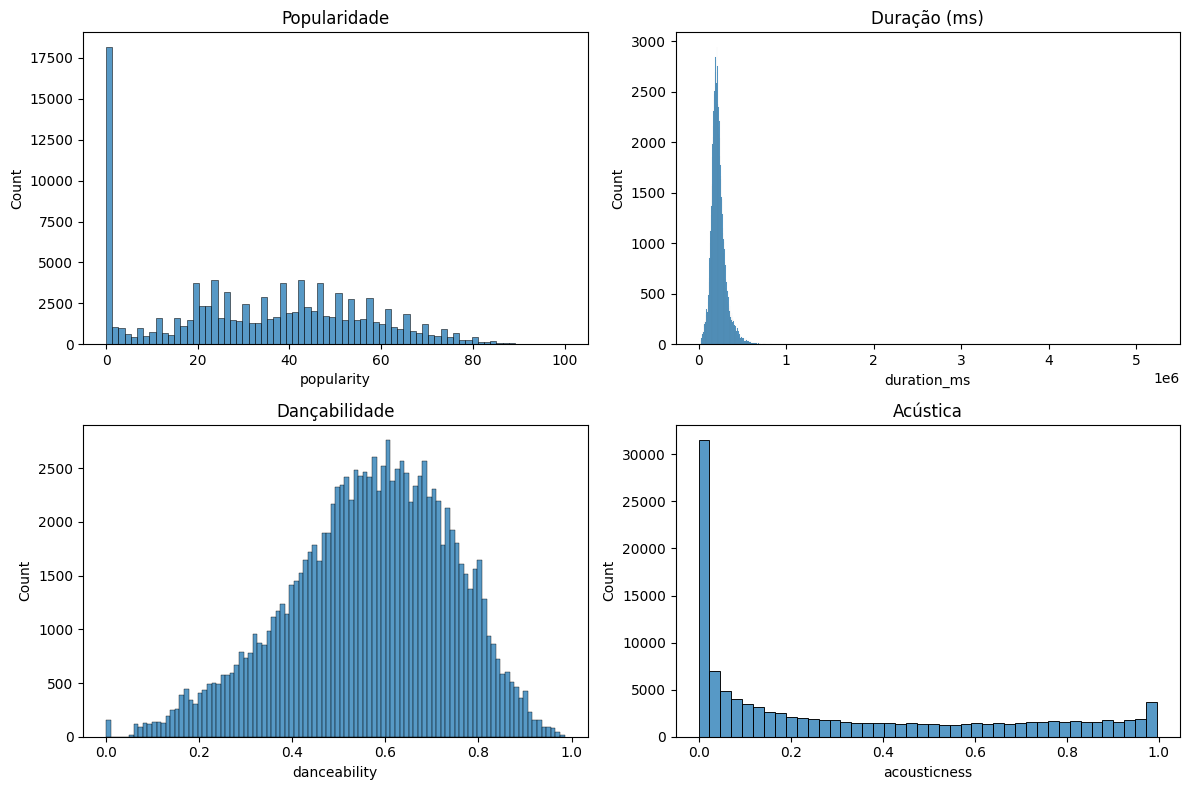

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
sns.histplot(df['popularity'], ax=axes[0, 0]).set_title('Popularidade')
sns.histplot(df['duration_ms'], ax=axes[0, 1]).set_title('Duração (ms)')
sns.histplot(df['danceability'], ax=axes[1, 0]).set_title('Dançabilidade')
sns.histplot(df['acousticness'], ax=axes[1, 1]).set_title('Acústica')
plt.tight_layout()
plt.show()

## PCA

In [10]:
spark = (
    SparkSession.builder
    .master("local[*]")
    .appName("PCA")
    .config("spark.driver.memory", "4g")
    #.config("spark.executor.memory", "4g")
    .getOrCreate()
)

In [11]:
schema = StructType([
    StructField("Unnamed: 0", IntegerType()),
    StructField("track_id", StringType()),
    StructField("artists", StringType()),
    StructField("album_name", StringType()),
    StructField("track_name", StringType()),
    StructField("popularity", IntegerType()),
    StructField("duration_ms", IntegerType()),
    StructField("explicit", BooleanType()),
    StructField("danceability", DoubleType()),
    StructField("energy", DoubleType()),
    StructField("key", BooleanType()),
    StructField("loudness", DoubleType()),
    StructField("mode", IntegerType()),
    StructField("speechiness", DoubleType()),
    StructField("acousticness", DoubleType()),
    StructField("instrumentalness", DoubleType()),
    StructField("liveness", DoubleType()),
    StructField("valence", DoubleType()),
    StructField("tempo", DoubleType()),
    StructField("time_signature", IntegerType()),
    StructField("track_genre", StringType())
])


In [ ]:
df_spark = (
    spark.read
    #.option('encoding', 'iso-8859-1') # 'latin1'
    #.option('decimal', ',')
    .option('header', True)
    .schema(schema)
    .csv('dados/dataset.csv') # pasta dos arquivos
)

In [14]:
print("Linhas no df_spark:", df_spark.count())
df_spark.limit(5).show()

Linhas no df_spark: 114000
+----------+--------------------+--------------------+--------------------+--------------------+----------+-----------+--------+------------+------+----+--------+----+-----------+------------+----------------+--------+-------+-------+--------------+-----------+
|Unnamed: 0|            track_id|             artists|          album_name|          track_name|popularity|duration_ms|explicit|danceability|energy| key|loudness|mode|speechiness|acousticness|instrumentalness|liveness|valence|  tempo|time_signature|track_genre|
+----------+--------------------+--------------------+--------------------+--------------------+----------+-----------+--------+------------+------+----+--------+----+-----------+------------+----------------+--------+-------+-------+--------------+-----------+
|         0|5SuOikwiRyPMVoIQD...|         Gen Hoshino|              Comedy|              Comedy|        73|     230666|   false|       0.676| 0.461|NULL|  -6.746|   0|      0.143|      0.

In [15]:
df_spark = df_spark.drop('Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name', 'track_genre', 'key', 'mode', 'explicit')

In [16]:
print("Linhas no df_spark:", df_spark.count())
df_spark.show(5)

Linhas no df_spark: 114000
+----------+-----------+------------+------+--------+-----------+------------+----------------+--------+-------+-------+--------------+
|popularity|duration_ms|danceability|energy|loudness|speechiness|acousticness|instrumentalness|liveness|valence|  tempo|time_signature|
+----------+-----------+------------+------+--------+-----------+------------+----------------+--------+-------+-------+--------------+
|        73|     230666|       0.676| 0.461|  -6.746|      0.143|      0.0322|         1.01E-6|   0.358|  0.715| 87.917|             4|
|        55|     149610|        0.42| 0.166| -17.235|     0.0763|       0.924|         5.56E-6|   0.101|  0.267| 77.489|             4|
|        57|     210826|       0.438| 0.359|  -9.734|     0.0557|        0.21|             0.0|   0.117|   0.12| 76.332|             4|
|        71|     201933|       0.266|0.0596| -18.515|     0.0363|       0.905|         7.07E-5|   0.132|  0.143| 181.74|             3|
|        82|     1988

In [17]:
df_spark.columns #quis remover o boleano pq fiquei com medo de interferir muito na análise, mas se for necessário posso colocar ele de volta

['popularity',
 'duration_ms',
 'danceability',
 'energy',
 'loudness',
 'speechiness',
 'acousticness',
 'instrumentalness',
 'liveness',
 'valence',
 'tempo',
 'time_signature']

| Coluna | Descrição | Tipo |
| --- | --- | --- |
| key | tonalidade da música (0–11, representando C, C#, D, ... B em notação cromática) | Numérica discreta |
| mode | maior (1) ou menor (0) — a escala da música | Binária |
| valence | medida de positividade/felicidade (0–1). Quanto maior, mais alegre/positiva a música | Contínua |
| tempo | velocidade em BPM (batidas por minuto). Ex: 120 BPM = andamento moderado | Contínua |
| time_signature | compasso/assinatura de tempo (ex: 4/4, 3/4) | Discreta; geralmente 4 é mais comum em pop/rock |

ao meu ver, vale a pena deixar o valence, tempo e time signature talvez

In [18]:
df_spark.dtypes

[('popularity', 'int'),
 ('duration_ms', 'int'),
 ('danceability', 'double'),
 ('energy', 'double'),
 ('loudness', 'double'),
 ('speechiness', 'double'),
 ('acousticness', 'double'),
 ('instrumentalness', 'double'),
 ('liveness', 'double'),
 ('valence', 'double'),
 ('tempo', 'double'),
 ('time_signature', 'int')]

In [19]:
print("Linhas no df_spark:", df_spark.count())
df_spark.show(5)

Linhas no df_spark: 114000
+----------+-----------+------------+------+--------+-----------+------------+----------------+--------+-------+-------+--------------+
|popularity|duration_ms|danceability|energy|loudness|speechiness|acousticness|instrumentalness|liveness|valence|  tempo|time_signature|
+----------+-----------+------------+------+--------+-----------+------------+----------------+--------+-------+-------+--------------+
|        73|     230666|       0.676| 0.461|  -6.746|      0.143|      0.0322|         1.01E-6|   0.358|  0.715| 87.917|             4|
|        55|     149610|        0.42| 0.166| -17.235|     0.0763|       0.924|         5.56E-6|   0.101|  0.267| 77.489|             4|
|        57|     210826|       0.438| 0.359|  -9.734|     0.0557|        0.21|             0.0|   0.117|   0.12| 76.332|             4|
|        71|     201933|       0.266|0.0596| -18.515|     0.0363|       0.905|         7.07E-5|   0.132|  0.143| 181.74|             3|
|        82|     1988

In [20]:
df_spark=df_spark.dropna()

In [21]:
assembler = VectorAssembler(inputCols=['popularity',
 'duration_ms',
 'danceability',
 'energy',
 'loudness',
 'speechiness',
 'acousticness',
 'instrumentalness',
 'liveness',
 'valence',
 'tempo',
 'time_signature'], outputCol="features")
vetor = assembler.transform(df_spark)

In [22]:
print("Linhas no df_spark:", df_spark.count())
print("Linhas no vetor:", vetor.count())
vetor.show(5)

Linhas no df_spark: 113866
Linhas no vetor: 113866
+----------+-----------+------------+------+--------+-----------+------------+----------------+--------+-------+-------+--------------+--------------------+
|popularity|duration_ms|danceability|energy|loudness|speechiness|acousticness|instrumentalness|liveness|valence|  tempo|time_signature|            features|
+----------+-----------+------------+------+--------+-----------+------------+----------------+--------+-------+-------+--------------+--------------------+
|        73|     230666|       0.676| 0.461|  -6.746|      0.143|      0.0322|         1.01E-6|   0.358|  0.715| 87.917|             4|[73.0,230666.0,0....|
|        55|     149610|        0.42| 0.166| -17.235|     0.0763|       0.924|         5.56E-6|   0.101|  0.267| 77.489|             4|[55.0,149610.0,0....|
|        57|     210826|       0.438| 0.359|  -9.734|     0.0557|        0.21|             0.0|   0.117|   0.12| 76.332|             4|[57.0,210826.0,0....|
|      

In [23]:
scaler = StandardScaler(inputCol="features", outputCol="scaled_features", withMean=True,withStd=True)
scaler_model = scaler.fit(vetor)
df_scaled = scaler_model.transform(vetor)

In [24]:
pca = PCA(
    k=11,
    inputCol="scaled_features",
    outputCol="score"
)

modelo_pca = pca.fit(df_scaled)
df_pca = modelo_pca.transform(df_scaled)

In [28]:
variancia = modelo_pca.explainedVariance.toArray()
print("Variância explicada por componente:", variancia)
print("Variância acumulada:", np.cumsum(variancia))

Variância explicada por componente: [0.24596732 0.12758747 0.10538756 0.08781674 0.0820001  0.07509563
 0.06945524 0.06937665 0.06092526 0.03750471 0.02719433 0.01168898]
Variância acumulada: [0.24596732 0.37355479 0.47894236 0.56675909 0.64875919 0.72385482
 0.79331006 0.86268671 0.92361198 0.96111669 0.98831102 1.        ]


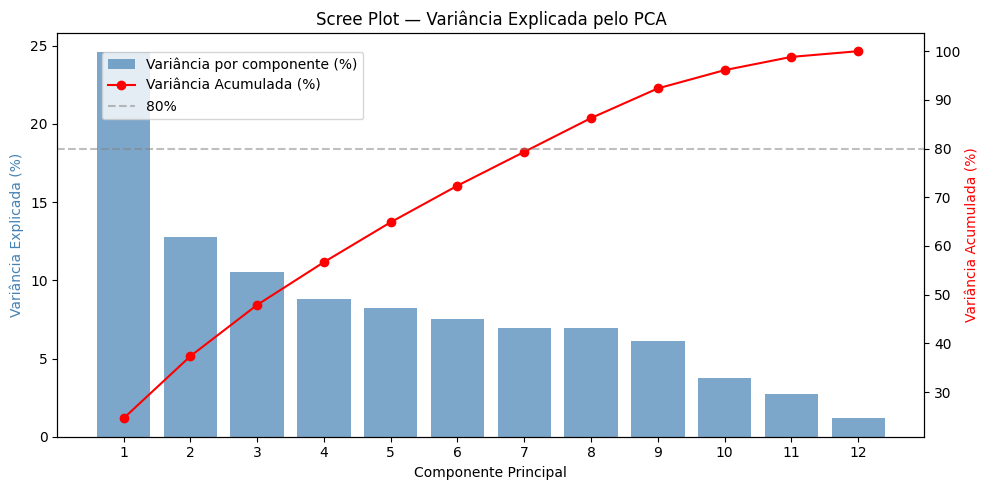


Componentes para explicar 80% da variância: 8


In [29]:
# Scree Plot
variancia_acumulada = np.cumsum(variancia)

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.bar(range(1, 13), variancia * 100, color='steelblue', alpha=0.7, label='Variância por componente (%)')
ax1.set_xlabel('Componente Principal')
ax1.set_ylabel('Variância Explicada (%)', color='steelblue')
ax1.set_xticks(range(1, 13))

ax2 = ax1.twinx()
ax2.plot(range(1, 13), variancia_acumulada * 100, 'ro-', label='Variância Acumulada (%)')
ax2.set_ylabel('Variância Acumulada (%)', color='red')
ax2.axhline(y=80, color='gray', linestyle='--', alpha=0.5, label='80%')

plt.title('Scree Plot — Variância Explicada pelo PCA')
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.9))
plt.tight_layout()
plt.show()

n_componentes_80 = int(np.argmax(variancia_acumulada >= 0.80)) + 1
print(f"\nComponentes para explicar 80% da variância: {n_componentes_80}")

In [30]:
# PCA final com apenas os componentes necessários
K_PCA = n_componentes_80

pca_final = PCA(k=K_PCA, inputCol="scaled_features", outputCol="pca_features")
modelo_pca_final = pca_final.fit(df_scaled)
df_pca_final = modelo_pca_final.transform(df_scaled)

print(f"PCA reduzido para {K_PCA} componentes.")
print(f"Variância acumulada: {modelo_pca_final.explainedVariance.toArray().sum()*100:.1f}%")

PCA reduzido para 8 componentes.
Variância acumulada: 86.3%


## Modelo de Agrupamento

### K-Means

K=2 | WSSSE=953778.94
K=3 | WSSSE=860339.52
K=4 | WSSSE=807885.65
K=5 | WSSSE=766307.77
K=6 | WSSSE=692890.86
K=7 | WSSSE=648943.94
K=8 | WSSSE=604832.32
K=9 | WSSSE=574091.03
K=10 | WSSSE=557062.57


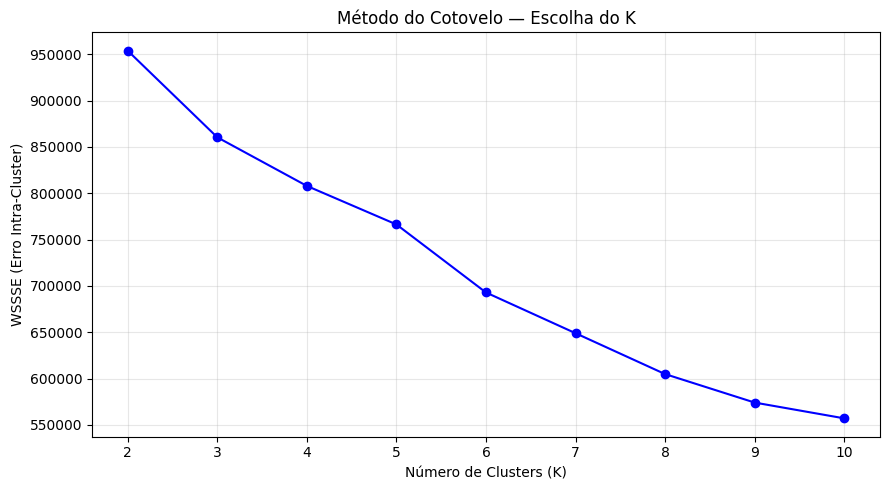

In [33]:
custos = []
ks = range(2, 11)

for k in ks:
    kmeans = KMeans(k=k, seed=42, featuresCol="pca_features", predictionCol="cluster")
    modelo_k = kmeans.fit(df_pca_final)
    custo = modelo_k.summary.trainingCost
    custos.append(custo)
    print(f"K={k} | WSSSE={custo:.2f}")

plt.figure(figsize=(9, 5))
plt.plot(ks, custos, 'bo-')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('WSSSE (Erro Intra-Cluster)')
plt.title('Método do Cotovelo — Escolha do K')
plt.xticks(ks)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [34]:
K_ESCOLHIDO = 6

kmeans_final = KMeans(k=K_ESCOLHIDO, seed=42,
                      featuresCol="pca_features",
                      predictionCol="cluster")
modelo_kmeans = kmeans_final.fit(df_pca_final)
df_clusterizado = modelo_kmeans.transform(df_pca_final)

print("Distribuição dos clusters:")
df_clusterizado.groupBy("cluster").count().orderBy("cluster").show()

Distribuição dos clusters:
+-------+-----+
|cluster|count|
+-------+-----+
|      0|26832|
|      1|12056|
|      2|38822|
|      3| 2962|
|      4| 8188|
|      5|25006|
+-------+-----+



In [35]:
# Silhouette Score — varia de -1 a 1, quanto mais próximo de 1 melhor
evaluator = ClusteringEvaluator(featuresCol="pca_features",
                                predictionCol="cluster",
                                metricName="silhouette")
silhouette = evaluator.evaluate(df_clusterizado)
print(f"Silhouette Score (K={K_ESCOLHIDO}): {silhouette:.4f}")

Silhouette Score (K=6): 0.2372


## Análise dos padrões

In [39]:
cols = ['popularity',
 'duration_ms',
 'danceability',
 'energy',
 'loudness',
 'speechiness',
 'acousticness',
 'instrumentalness',
 'liveness',
 'valence',
 'tempo',
 'time_signature']

# Médias dos atributos originais por cluster
medias_cluster = (
    df_clusterizado
    .select(cols + ['cluster'])
    .groupBy('cluster')
    .agg(*[F.round(F.avg(c), 4).alias(c) for c in cols])
    .orderBy('cluster')
)
medias_cluster.show(truncate=False)

+-------+----------+-----------+------------+------+--------+-----------+------------+----------------+--------+-------+--------+--------------+
|cluster|popularity|duration_ms|danceability|energy|loudness|speechiness|acousticness|instrumentalness|liveness|valence|tempo   |time_signature|
+-------+----------+-----------+------------+------+--------+-----------+------------+----------------+--------+-------+--------+--------------+
|0      |38.444    |230494.5986|0.4639      |0.827 |-5.3604 |0.0832     |0.1027      |0.0496          |0.3334  |0.4039 |140.1811|3.9358        |
|1      |26.2886   |332263.3604|0.5636      |0.7486|-8.3532 |0.0683     |0.0763      |0.6734          |0.1597  |0.2933 |125.4724|3.9488        |
|2      |31.4293   |208940.3227|0.6948      |0.7354|-6.1234 |0.0837     |0.1869      |0.027           |0.1618  |0.6686 |118.505 |3.9956        |
|3      |30.1364   |202589.7637|0.6376      |0.6481|-9.1215 |0.5588     |0.4899      |0.0309          |0.4305  |0.5055 |115.3021|3

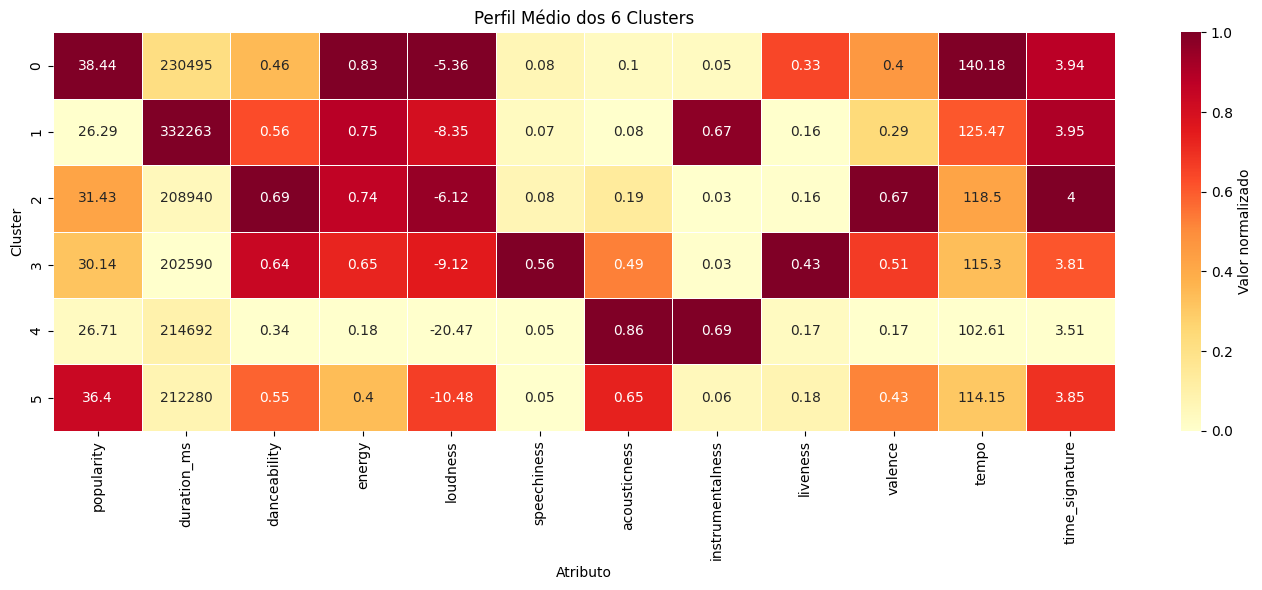

In [40]:
# Heatmap dos perfis de cada cluster
df_medias = medias_cluster.toPandas().set_index('cluster')
df_norm = (df_medias - df_medias.min()) / (df_medias.max() - df_medias.min())

plt.figure(figsize=(14, 6))
sns.heatmap(df_norm, annot=df_medias.round(2), fmt='g',
            cmap='YlOrRd', linewidths=0.5,
            cbar_kws={'label': 'Valor normalizado'})
plt.title(f'Perfil Médio dos {K_ESCOLHIDO} Clusters')
plt.xlabel('Atributo')
plt.ylabel('Cluster')
plt.tight_layout()
plt.show()